In [21]:
import pandas as pd
from dateutil import parser
from datetime import datetime
import pytz
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import seaborn as sns
import plotly.graph_objects as go

# Load data
articles = pd.read_csv("../../data/processed/gbh_geocoded_output.csv")
demographics = pd.read_csv("../../data/processed/demographics_by_tract.csv")

# Drop unnecessary columns from demographics
demographics = demographics.drop(columns=["Index", "Name", "State", "County"])

# Drop rows without neighborhoods
articles.dropna(subset=["Neighborhood"], inplace=True)

# Dictionary to map timezone names to pytz time zones
tzinfos = {'EST': pytz.timezone('US/Eastern'), 'EDT': pytz.timezone('US/Eastern')}

# Function to convert date strings to datetime objects
def convert_to_datetime(date_str):
    return parser.parse(date_str, tzinfos=tzinfos)

# Apply the conversion function to the 'Publication Date' column
articles['Publication Date'] = articles['Publication Date'].apply(convert_to_datetime)

# Ensure the Publication Date column is timezone-aware
articles['Publication Date'] = articles['Publication Date'].dt.tz_convert(pytz.timezone('US/Eastern'))

In [22]:
# Define the date range (example)
start_date = pytz.timezone('US/Eastern').localize(datetime(2023, 3, 1)) # This is the month with most published articles on the given data set
end_date = pytz.timezone('US/Eastern').localize(datetime(2023, 4, 1))

# Filter the DataFrame for the date range
filtered_articles = articles[(articles['Publication Date'] >= start_date) & (articles['Publication Date'] <= end_date)]

print(f"Using articles from {start_date.date()} to {end_date.date()}")


Using articles from 2023-03-01 to 2023-04-01


In [23]:
# Function to merge articles with demographics
def merge_articles_with_demographics(articles_df, demographics_df):
    merged_df = pd.merge(articles_df, demographics_df, on='Census Tract', how='left')
    return merged_df

merged_articles = merge_articles_with_demographics(filtered_articles, demographics)

In [24]:
# Get topic distribution
def get_topic_distribution(df, name, demographic):
    return df[df[name] == demographic]["Closest Topic"].value_counts()

In [25]:
# Boston demographics https://www.census.gov/quickfacts/fact/table/bostoncitymassachusetts/PST045222
# Ignoring Two or More Races and Hispanic poulation
boston_demographics = {"White": 0.5985, "African American": 0.2771, "Asian": 0.1195, "American Indian and Alaska Native": 0.003695, "Native Hawaiian and Other Pacific Island":0.001232, "Other": 0}

# Convert the dictionary to a DataFrame
boston_demographics_df = pd.DataFrame(list(boston_demographics.items()), columns=['Race', 'Population'])
boston_demographics_df = boston_demographics_df.reset_index(drop=True)
boston_demographics_df["Population"] = round(boston_demographics_df["Population"]*100,2)

# Overall Boston statistics
def get_boston_stats(df):
    topic_distribution = df["Closest Topic"].value_counts()
    article_count = len(df)

    return {
        "Topic Distribution": topic_distribution,
        "Article Count": article_count,
        "Race Distribution": boston_demographics_df,
    }

C:\Users\axel0\AppData\Local\Temp\ipykernel_7340\4223562305.py:51: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




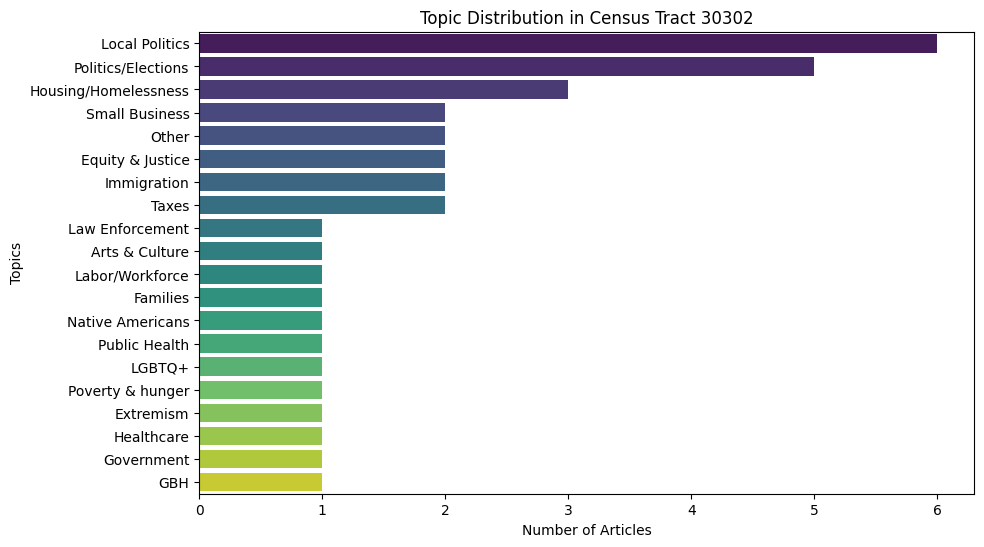

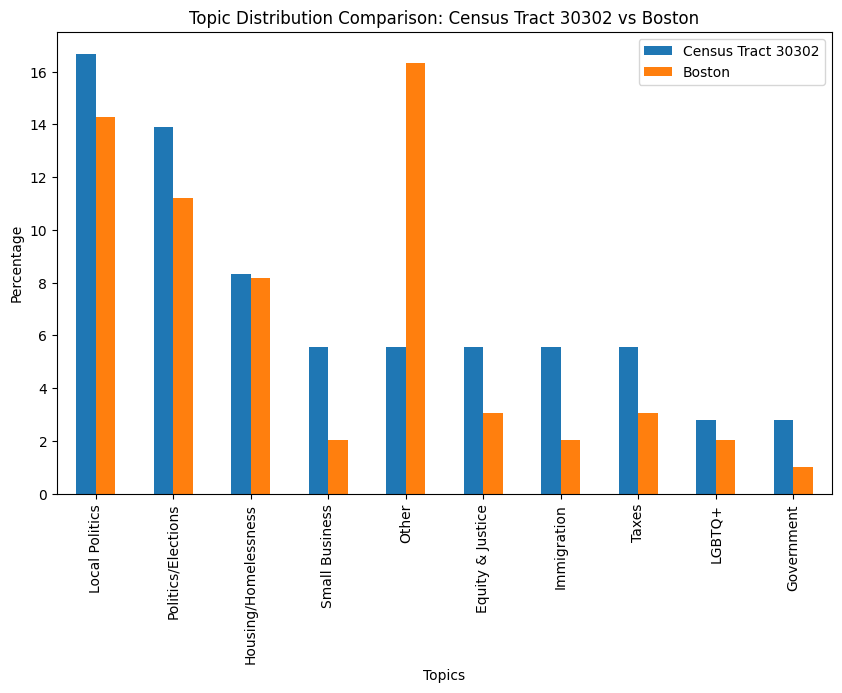

<Figure size 1200x600 with 0 Axes>

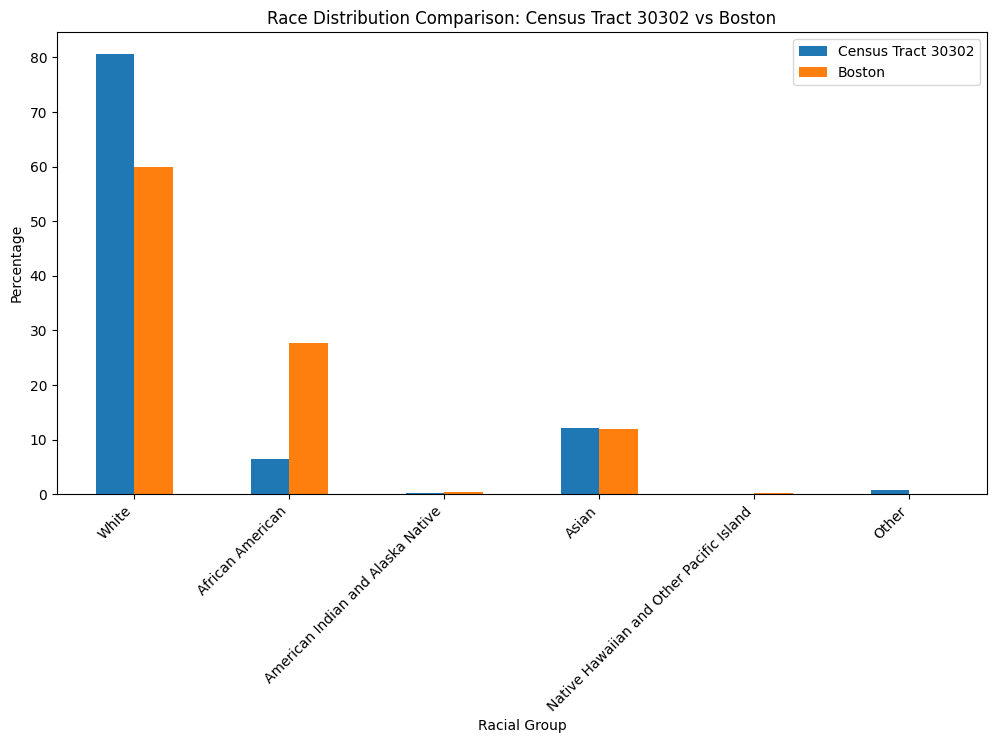

In [29]:
def get_census_tract_stats(df, census_tract):
    topic_distribution = get_topic_distribution(df, "Census Tract", census_tract)
    article_count = df["Census Tract"].value_counts()[census_tract]
    race_distribution = get_race_distribution(df, census_tract)
    
    return {
        "Topic Distribution": topic_distribution,
        "Topic Count": len(topic_distribution),
        "Article Count": article_count,
        "Race Distribution": race_distribution.reset_index(drop=True)
    }

# Calculate race distribution for a specific census tract
def get_race_distribution(df, census_tract):
    tract_data = df[df['Census Tract'] == census_tract]
    race_distribution = tract_data[['White', 'African American', 'American Indian and Alaska Native', 'Asian', 'Native Hawaiian and Other Pacific Island', 'Other']].sum()
    total_population = race_distribution.sum()
    race_distribution_percentage = round((race_distribution * 100 / total_population), 2)

    # Convert the dictionary to a DataFrame
    tract_demographics_df = pd.DataFrame(list(race_distribution_percentage.items()), columns=['Race', 'Population'])

    return tract_demographics_df

# Compare census tract to Boston
def compare_tract_to_boston(tract_stats, boston_stats):
    comparison = {
        "Census Tract Article %": round(100 * tract_stats["Article Count"] / boston_stats["Article Count"], 0),
        "Census Tract Topic %": round(100 * (tract_stats["Topic Distribution"] / tract_stats["Article Count"]), 2),
        "Boston Topic %": round(100 * (boston_stats["Topic Distribution"] / boston_stats["Article Count"]), 2),
        "Census Tract Race %": tract_stats["Race Distribution"],
        "Boston Race %": boston_stats["Race Distribution"]
    }
    
    return comparison

# Example: Get stats for a specific census tract
census_tract = 30302
tract_stats = get_census_tract_stats(merged_articles, census_tract)

# Get Boston stats (already calculated previously)
boston_stats = get_boston_stats(filtered_articles)

# Compare census tract to Boston
comparison = compare_tract_to_boston(tract_stats, boston_stats)

### Visualize Comparisons for Census Tracts

# Visualize topic distribution for the census tract
plt.figure(figsize=(10, 6))
sns.barplot(x=tract_stats["Topic Distribution"].values, y=tract_stats["Topic Distribution"].index, palette="viridis")
plt.xlabel("Number of Articles")
plt.ylabel("Topics")
plt.title(f"Topic Distribution in Census Tract {census_tract}")
plt.show()

# Visualize the percentage of articles in Boston that come from the census tract
percentage = comparison["Census Tract Article %"]

# Data for the pie chart
labels = [f'Census Tract {census_tract}', 'Other Census Tracts']
values = [tract_stats["Article Count"], boston_stats["Article Count"] - tract_stats["Article Count"]]

# Pie chart
fig = go.Figure(data=[go.Pie(labels=labels, values=values)])
fig.update_layout(
    title_text=f'Percentage of Articles in Boston from Census Tract {census_tract}',
    width=550, 
    height=500,  
)
fig.show()

# Get the top 10 topics for the census tract
top_tract_topics = comparison["Census Tract Topic %"].sort_values(ascending=False).head(10)

# Filter Boston's topics to match the top 10 tract topics
boston_topics_filtered = comparison["Boston Topic %"].reindex(top_tract_topics.index)

# Visualize comparison of topic distribution
comparison_df = pd.DataFrame({
    f'Census Tract {census_tract}': top_tract_topics,
    "Boston": boston_topics_filtered
})

comparison_df.plot(kind='bar', figsize=(10, 6))
plt.xlabel("Topics")
plt.ylabel("Percentage")
plt.title(f"Topic Distribution Comparison: Census Tract {census_tract} vs Boston")
plt.show()

# Ensure race distributions are in the same format
tract_race_dist = comparison["Census Tract Race %"].set_index("Race")
boston_race_dist = comparison["Boston Race %"].set_index("Race")

# Combine tract and Boston race distributions into a DataFrame
race_comparison_df = pd.concat([tract_race_dist, boston_race_dist], axis=1)
race_comparison_df.columns = [f'Census Tract {census_tract}', "Boston"]

# Plot the race distribution comparison
plt.figure(figsize=(12, 6))
race_comparison_df.plot(kind='bar', figsize=(12, 6))
plt.xlabel("Racial Group")
plt.ylabel("Percentage")
plt.title(f"Race Distribution Comparison: Census Tract {census_tract} vs Boston")
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

# Pie chart for Race distribution for the top census tract
fig = px.pie(tract_stats["Race Distribution"], names=tract_stats["Race Distribution"]["Race"], values="Population", title=f'Census Tract {census_tract} Race Distribution')
fig.update_layout(width=800, height=600)
fig.show()